In [2]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import tangram as tg
import muon as mu
import anndata as ad

import os
import sys
from pathlib import Path

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Add the src directory to the path if it's not already there
notebook_dir = Path(os.getcwd())
if notebook_dir.name == 'src':
    sys.path.append(".")  # Add current directory
else:
    sys.path.append(str(notebook_dir / "src"))  # Add src directory

from config import H5AD_DIR, get_h5ad_path

In [44]:
# read ad objects

ad_sp = sc.read_h5ad(get_h5ad_path("c_sp_ad.h5ad"))

ad_rna = sc.read_h5ad(get_h5ad_path("c_sc_ad.h5ad"))

ad_atac_genes = sc.read_h5ad(get_h5ad_path("c_atac_genes_ad.h5ad"))

In [13]:
# Convert gene names to sets (case-insensitive comparison)
overlapping_genes = set(ad_rna.var_names.str.lower()) & set(ad_sp.var_names.str.lower())

In [18]:
tg.pp_adatas(ad_rna, ad_sp, genes=overlapping_genes)

INFO:root:235 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:235 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


In [19]:
ad_map = tg.map_cells_to_space(ad_rna, ad_sp,
    mode="cells",
#     mode="clusters",
#     cluster_label='cell_subclass',  # .obs field w cell types
    density_prior='rna_count_based',
    num_epochs=500,
    # device="cuda:0",
    device='cpu',
)

INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 235 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.355, KL reg: 0.071
Score: 0.900, KL reg: 0.002
Score: 0.907, KL reg: 0.001
Score: 0.909, KL reg: 0.001
Score: 0.910, KL reg: 0.001


INFO:root:Saving results..


In [20]:
ad_map.write_h5ad(str(H5AD_DIR / "c_map_ad.h5ad"))

In [22]:
tg.project_cell_annotations(ad_map, ad_sp, annotation="celltype")
copy_annotation_list = list(pd.unique(ad_rna.obs['celltype']))

INFO:root:spatial prediction dataframe is saved in `obsm` `tangram_ct_pred` of the spatial AnnData.


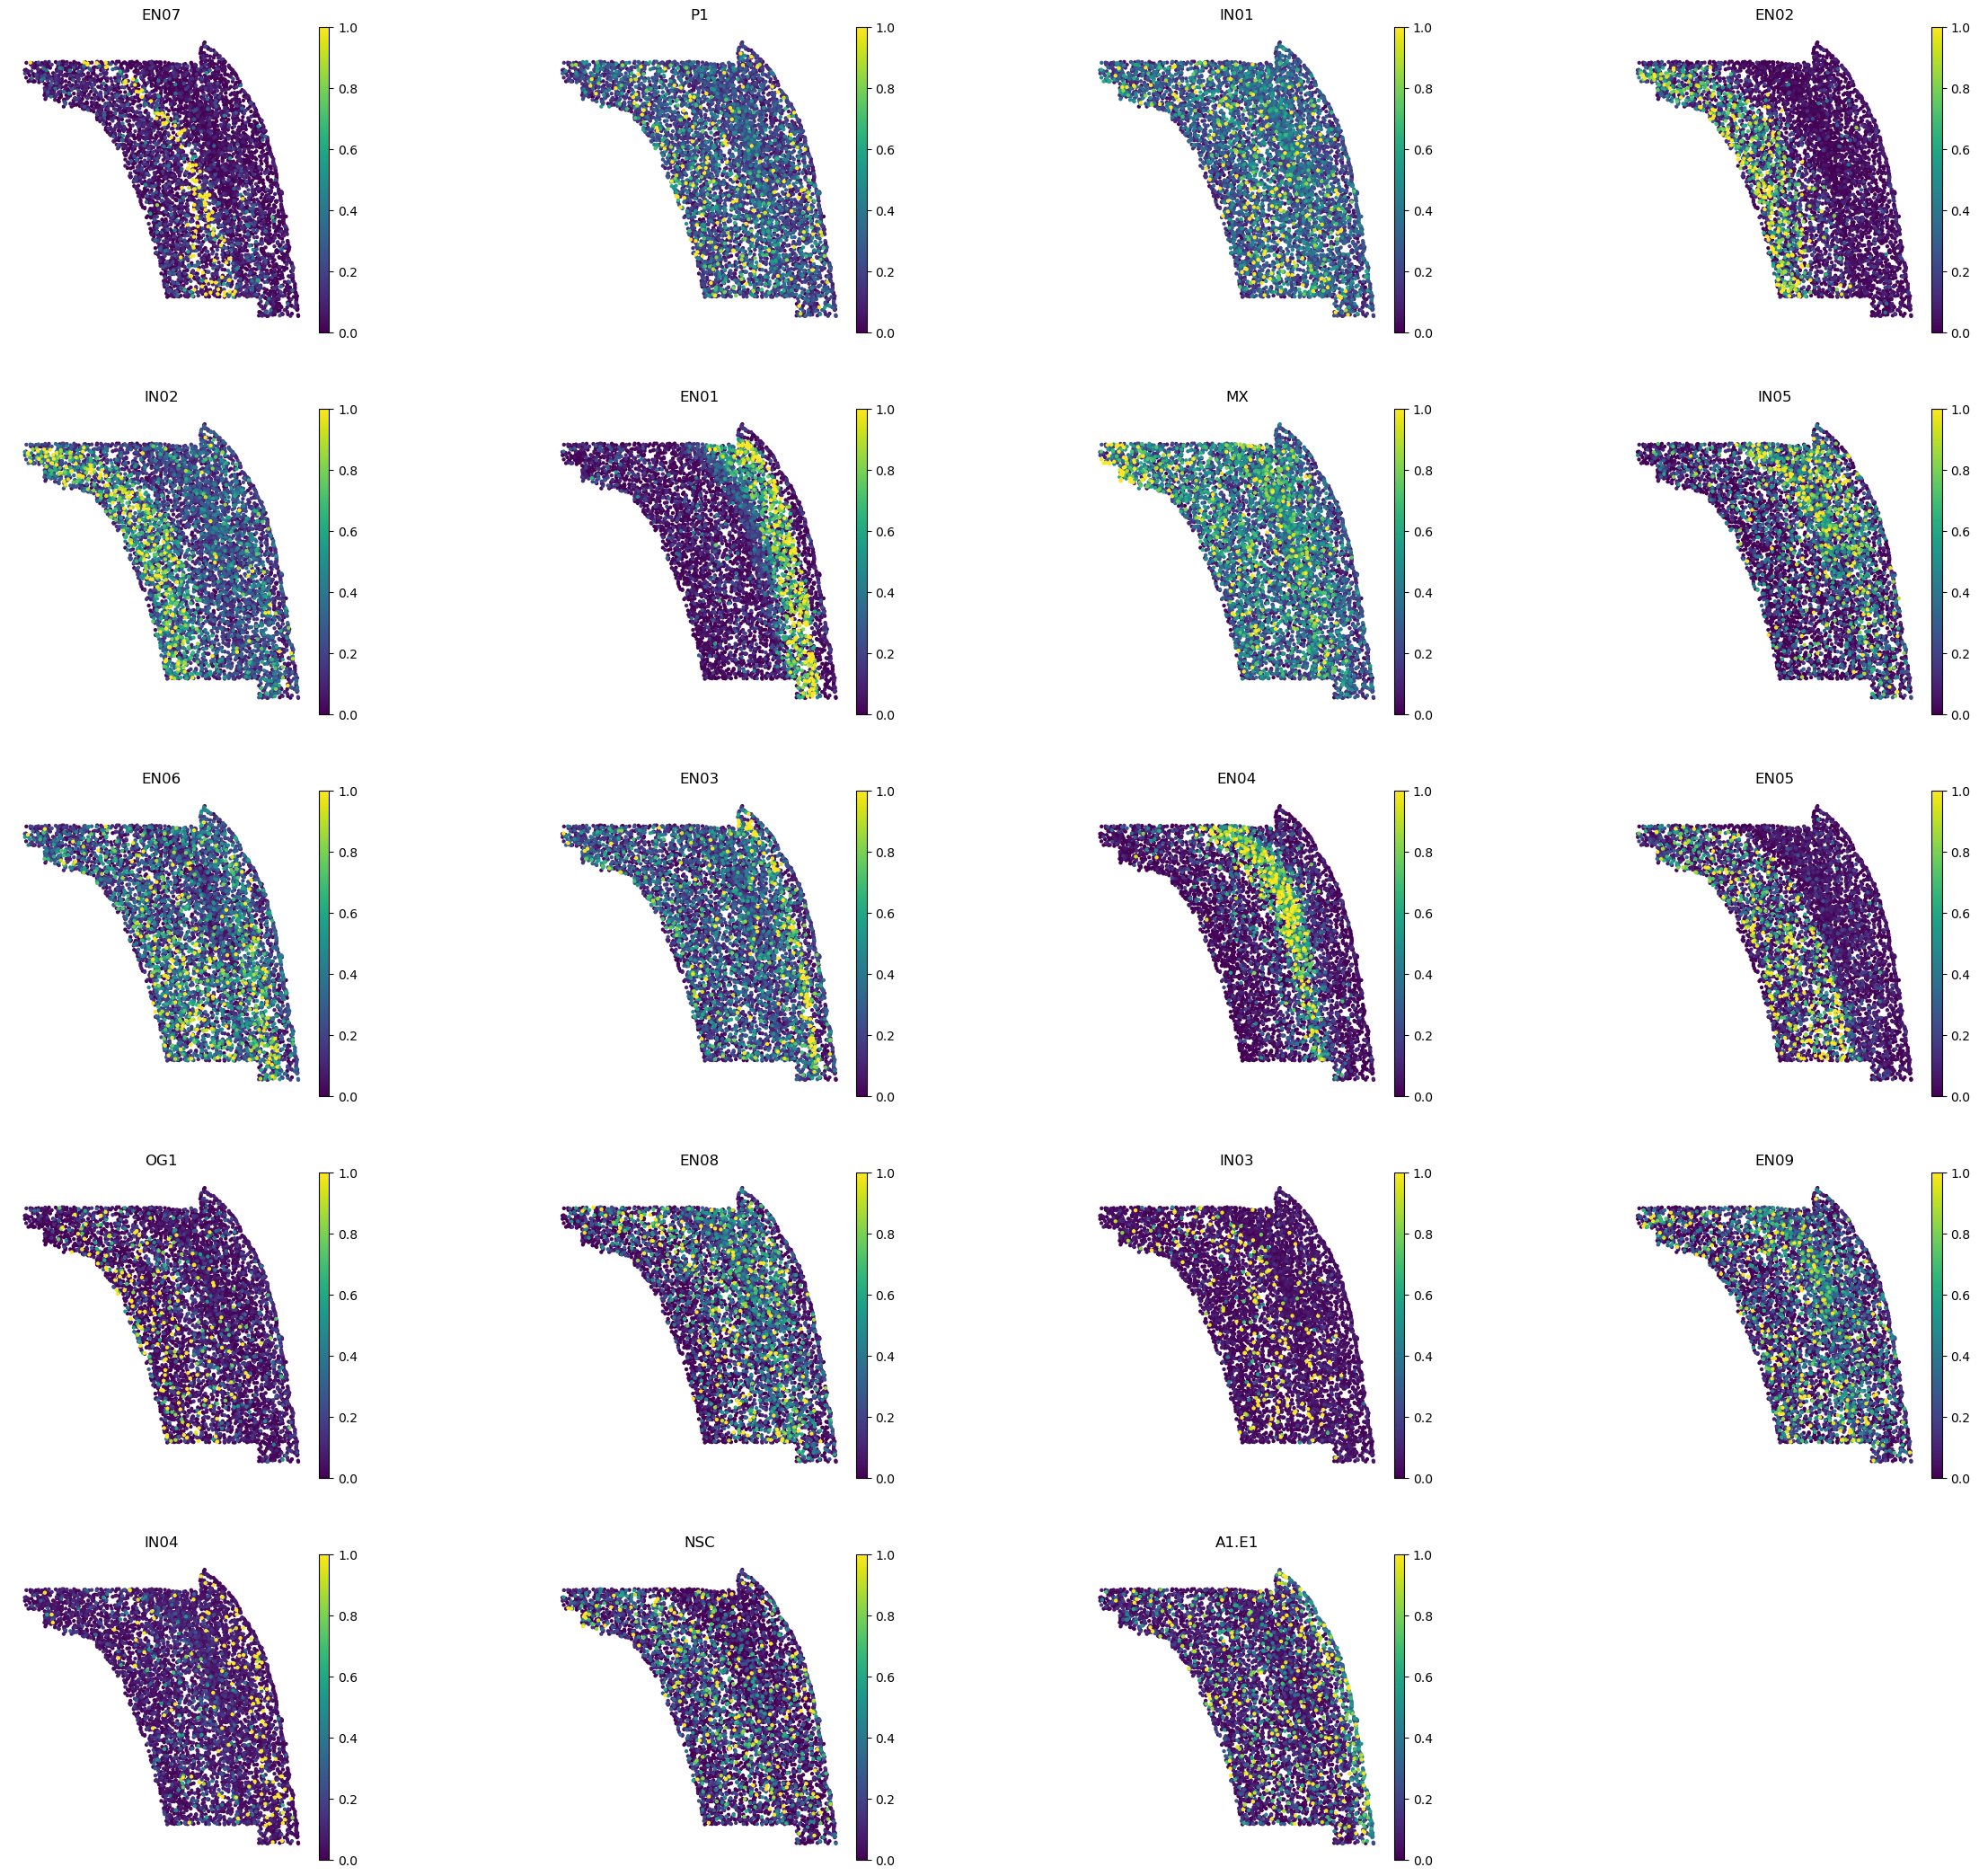

In [24]:
tg.plot_cell_annotation_sc(ad_sp, copy_annotation_list, spot_size=40, perc=0.02)

In [26]:
ad_ge = tg.project_genes(ad_map, ad_rna)

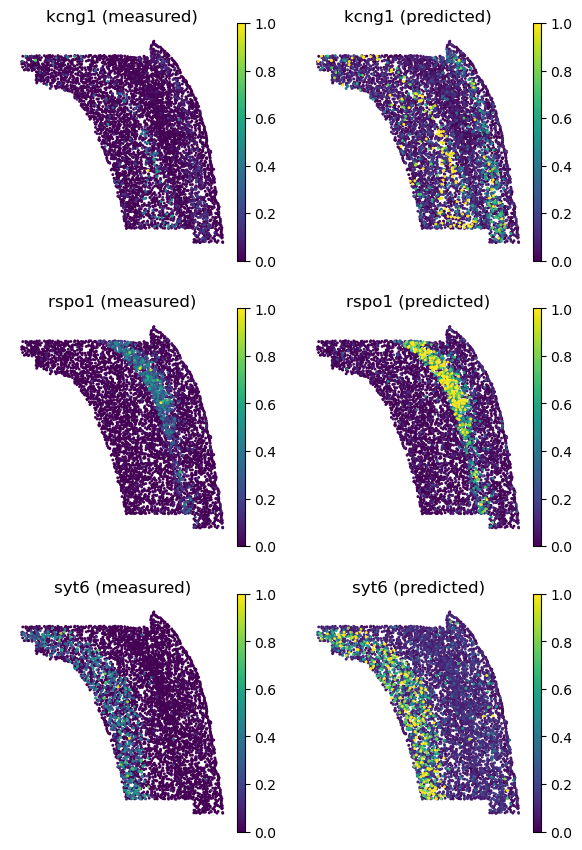

In [41]:
tg.plot_genes_sc(genes=["kcng1", "rspo1", "syt6"], adata_measured=ad_sp, adata_predicted=ad_ge, spot_size=40, perc=0.02,cmap="viridis")

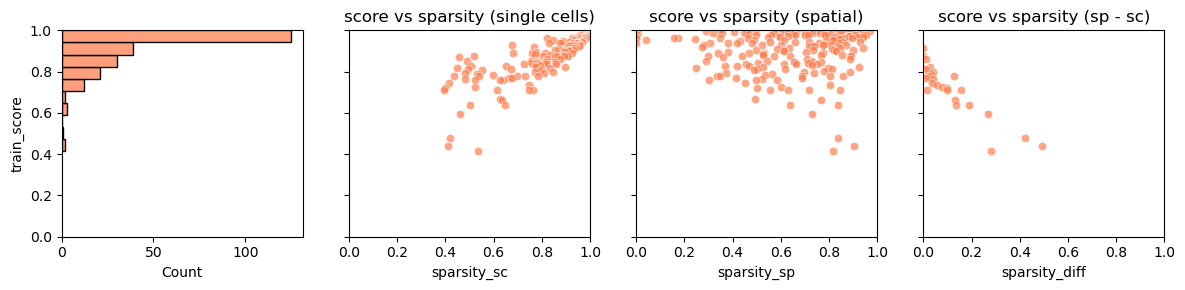

In [43]:
tg.plot_utils.plot_training_scores(ad_map)

In [49]:
ad_atac_genes.obs_names = ad_map.obs_names

In [52]:
gene_accessibility_spatial = tg.project_genes(ad_map, ad_atac_genes)

In [53]:
gene_accessibility_spatial

AnnData object with n_obs × n_vars = 5283 × 18683
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'cell_id', 'centroid_x', 'centroid_y', 'uniform_density', 'rna_count_based_density'
    var: 'chrom', 'start', 'end', 'Strand', 'gene_ids', 'n_cells', 'is_training'

In [54]:
gene_accessibility_spatial.obsm["spatial"] = np.array(gene_accessibility_spatial.obs[["centroid_x", "centroid_y"]])

In [61]:
gene_accessibility_spatial.write(get_h5ad_path("c_atac_spatial_ad.h5ad"))

## sp autocorr on atac

In [65]:
sq.gr.spatial_neighbors(gene_accessibility_spatial)

In [66]:
sq.gr.spatial_autocorr(gene_accessibility_spatial, mode="geary")

In [68]:
gene_accessibility_spatial.uns["gearyC"]

,C,pval_norm,var_norm,pval_norm_fdr_bh
zfpm2,0.853192,6.114548e-83,0.000058,2.284762e-79
cacna1e,0.865993,1.804781e-69,0.000058,5.619787e-66
gnb4,0.867139,2.530775e-68,0.000058,6.754638e-65
olfm3,0.867648,8.114913e-68,0.000058,1.895137e-64
meis2,0.870647,7.098828e-65,0.000058,1.473638e-61
...,...,...,...,...
s100g,1.062543,1.110223e-16,0.000058,1.123635e-15
4933427i04rik,1.067010,0.000000e+00,0.000058,0.000000e+00
eomes,1.067765,0.000000e+00,0.000058,0.000000e+00
gm13362,1.070225,0.000000e+00,0.000058,0.000000e+00


In [70]:
geary_gene_names_list = gene_accessibility_spatial.uns["gearyC"].head(n=20).index.tolist()
print(geary_gene_names_list)

['zfpm2', 'cacna1e', 'gnb4', 'olfm3', 'meis2', 'igsf21', 'dgki', 'lrrc1', 'klhl29', 'irgc1', 'khdrbs3', 'iqgap2', 'tenm2', 'slc39a11', 'c7', 'adgrl3', 'synpo', 'kcnma1', 'celf4', 'pappa2']


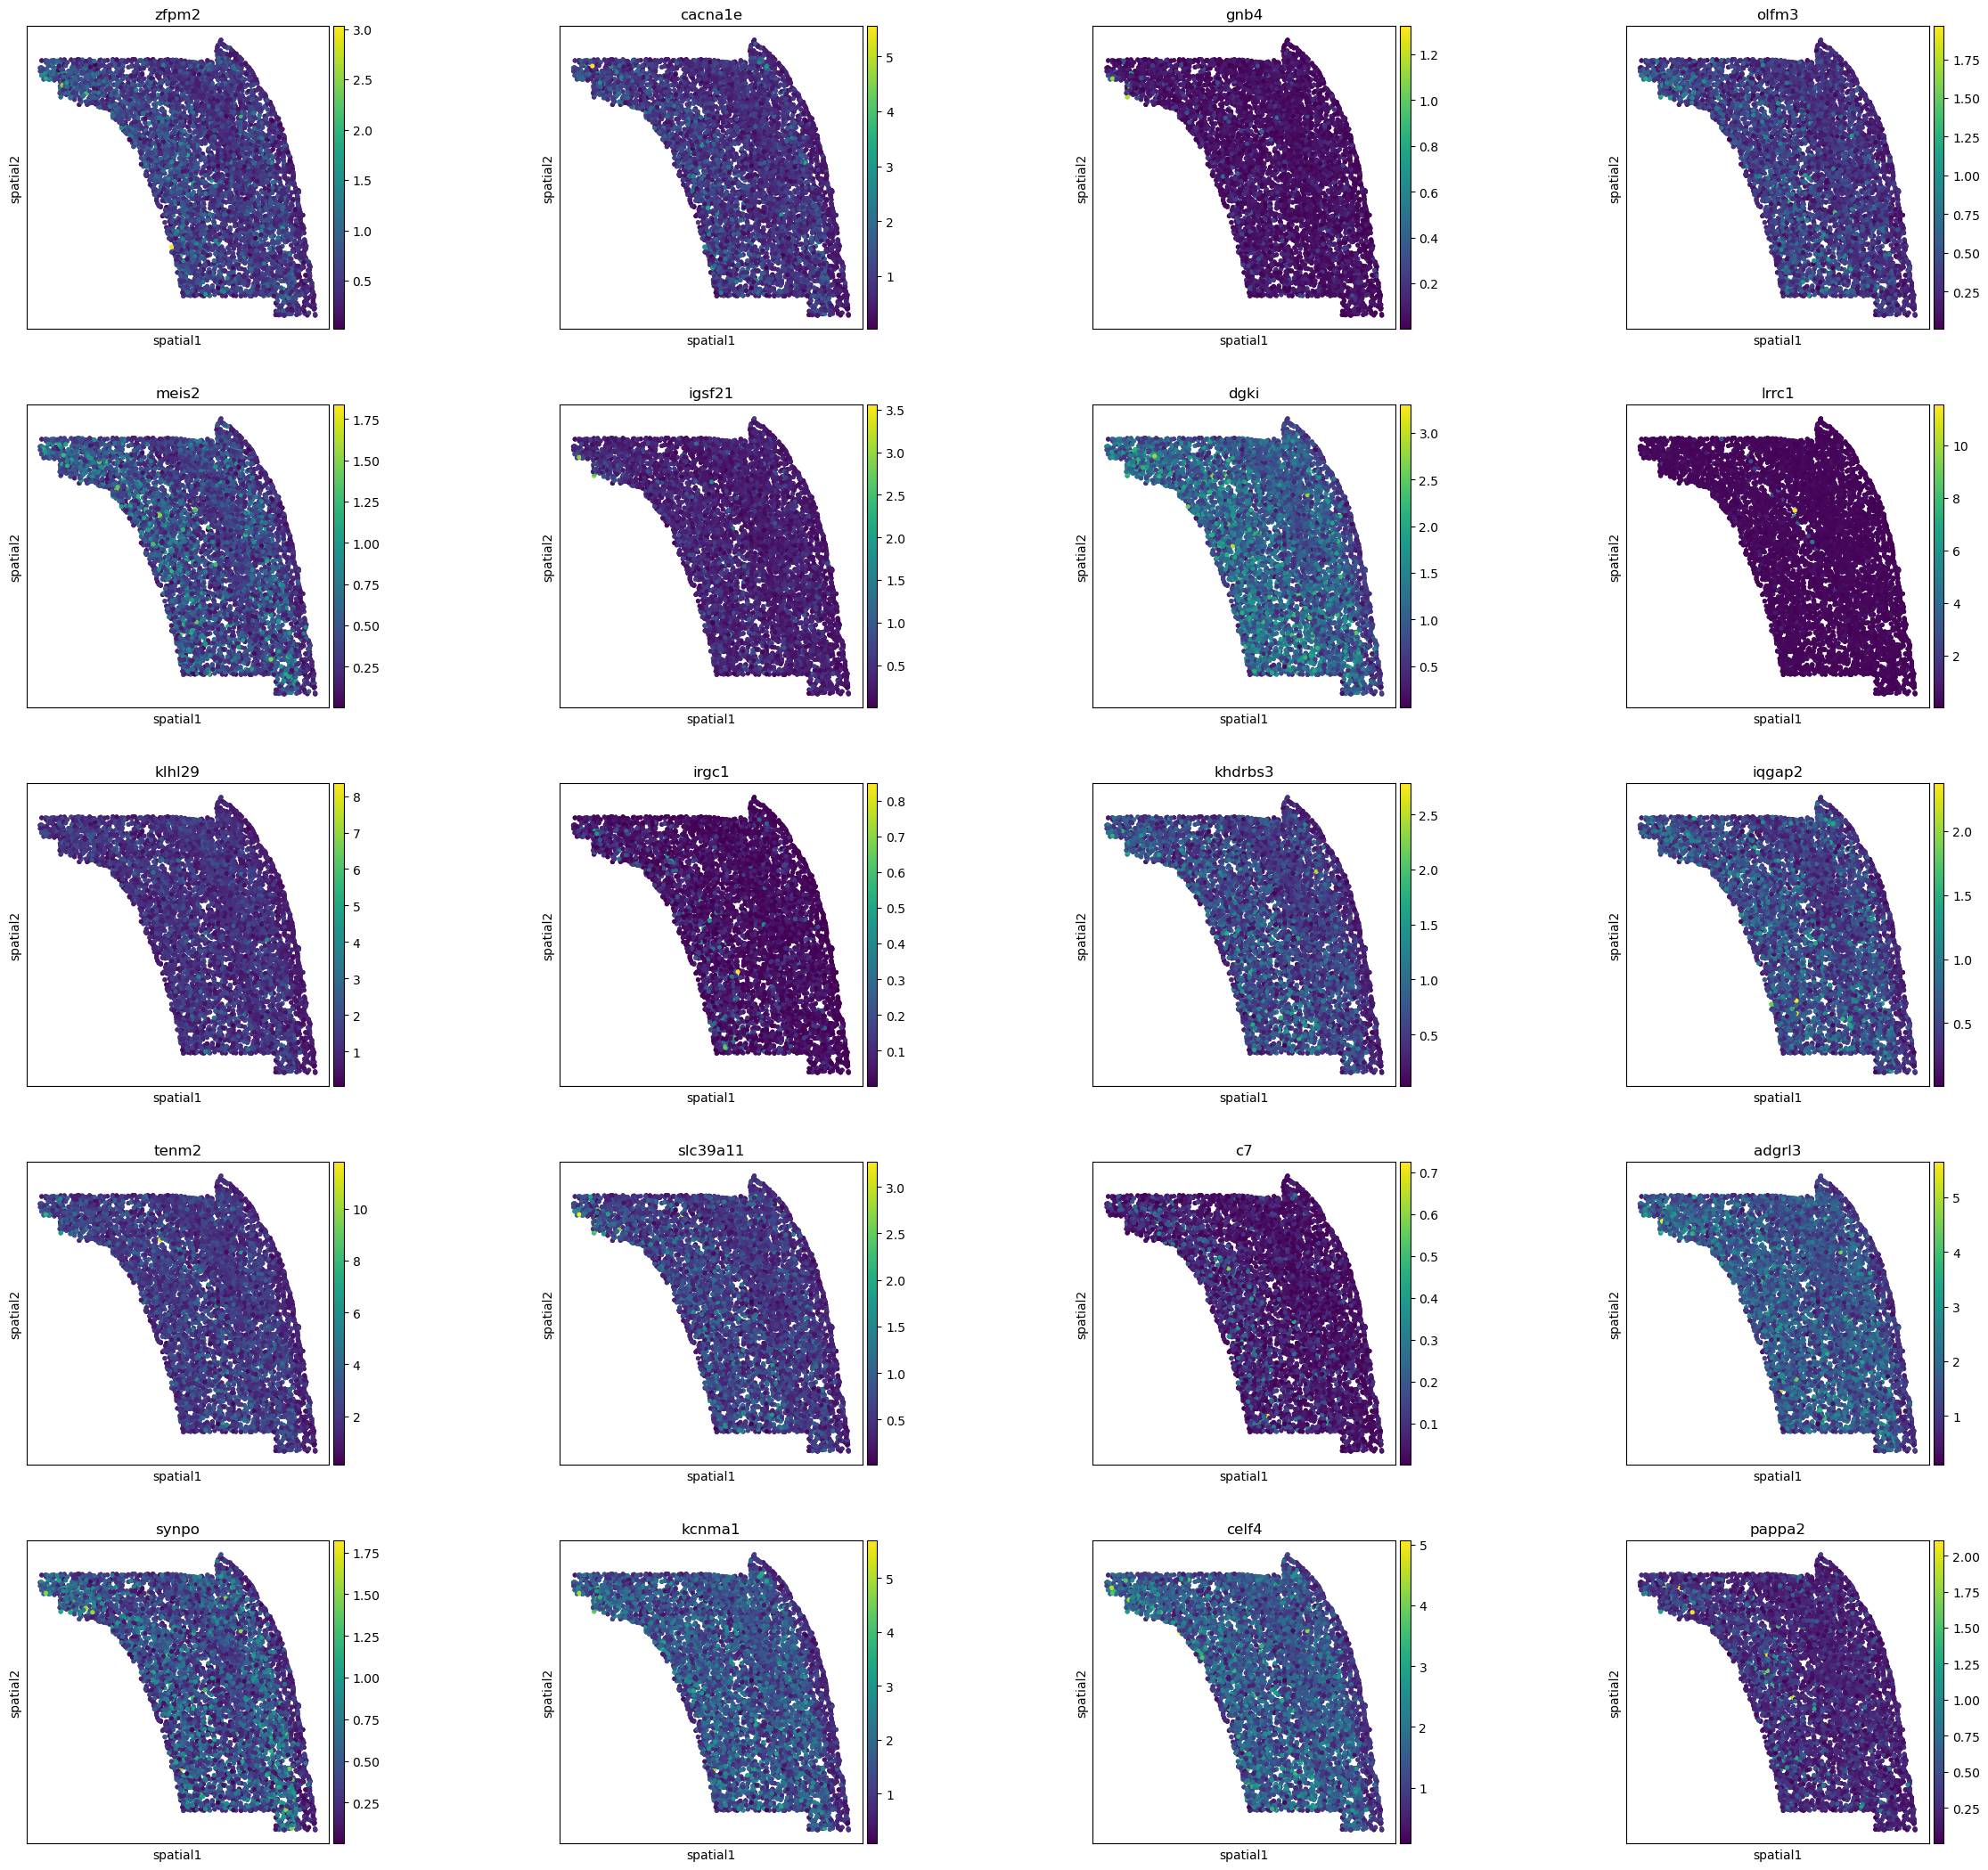

In [72]:
sq.pl.spatial_scatter(
    gene_accessibility_spatial, shape=None, color=geary_gene_names_list, size=30
)

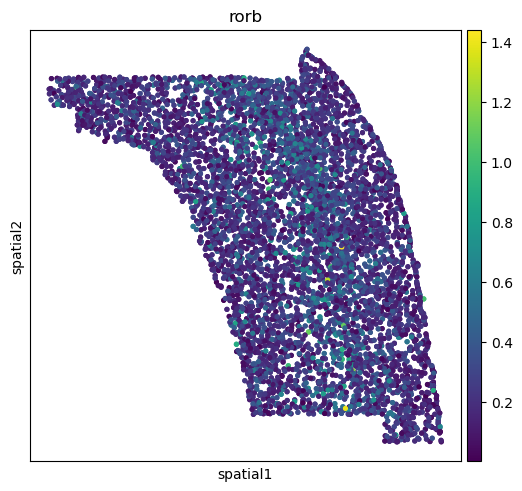

In [79]:
sq.pl.spatial_scatter(
    gene_accessibility_spatial, shape=None, color="rorb", size=30
)

In [78]:
"Rorb" in gene_accessibility_spatial.var_names

False

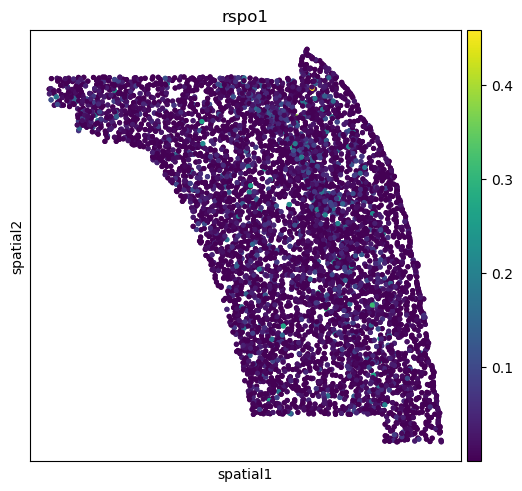

In [82]:
sq.pl.spatial_scatter(
    gene_accessibility_spatial, shape=None, color="rspo1", size=30
)